# **Part 1** — Using K-Means to cluster unlabeled customer data

## Problem Statement:
Imagine we are working for a distributor. The company knows how much each customer has spent 
on milk, vegetables, frozen food, etc. However, no one has grouped them into specific categories yet, 
such as "grocery shoppers" or "traditional food shoppers".

## Notebook Workflow:
Unlabeled data 
→ Clean and scale metrics 
→ K-Means clustering 
→ Human inspection & labeling 
→ Export labeled data for KNN.


## **I. Libraries and Data**

In [3]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

In [4]:
df = pd.read_csv("wholesale_customers.csv")

## **II. Getting Familiar with the Data**

Before applying the algorithm, we need to answer three simple questions:
- Are there any columns with missing data?
- What is the data type of each column?
- How large is the spending gap between different product categories?

The six spending columns often contain a few customers who spend significantly more than the rest. 
We use 'log1p' to "compress" these extremely large values, similar to zooming out on a map 
to see both nearby and distant points. After that, 'StandardScaler' is used to bring all columns 
to the same scale, preventing columns with larger numbers from automatically dominating the others.


In [5]:
FEATURES = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]

quality_report = pd.DataFrame({
    "dtype": df[FEATURES].dtypes.astype(str),
    "missing": df[FEATURES].isna().sum(),
    "unique": df[FEATURES].nunique(),
})
display(quality_report)
display(df[FEATURES].describe().T.round(1))

,dtype,missing,unique
Fresh,int64,0,433
Milk,int64,0,421
Grocery,int64,0,430
Frozen,int64,0,426
Detergents_Paper,int64,0,417
Delicassen,int64,0,403


,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.3,12647.3,3.0,3127.8,8504.0,16933.8,112151.0
Milk,440.0,5796.3,7380.4,55.0,1533.0,3627.0,7190.2,73498.0
Grocery,440.0,7951.3,9503.2,3.0,2153.0,4755.5,10655.8,92780.0
Frozen,440.0,3071.9,4854.7,25.0,742.2,1526.0,3554.2,60869.0
Detergents_Paper,440.0,2881.5,4767.9,3.0,256.8,816.5,3922.0,40827.0
Delicassen,440.0,1524.9,2820.1,3.0,408.2,965.5,1820.2,47943.0


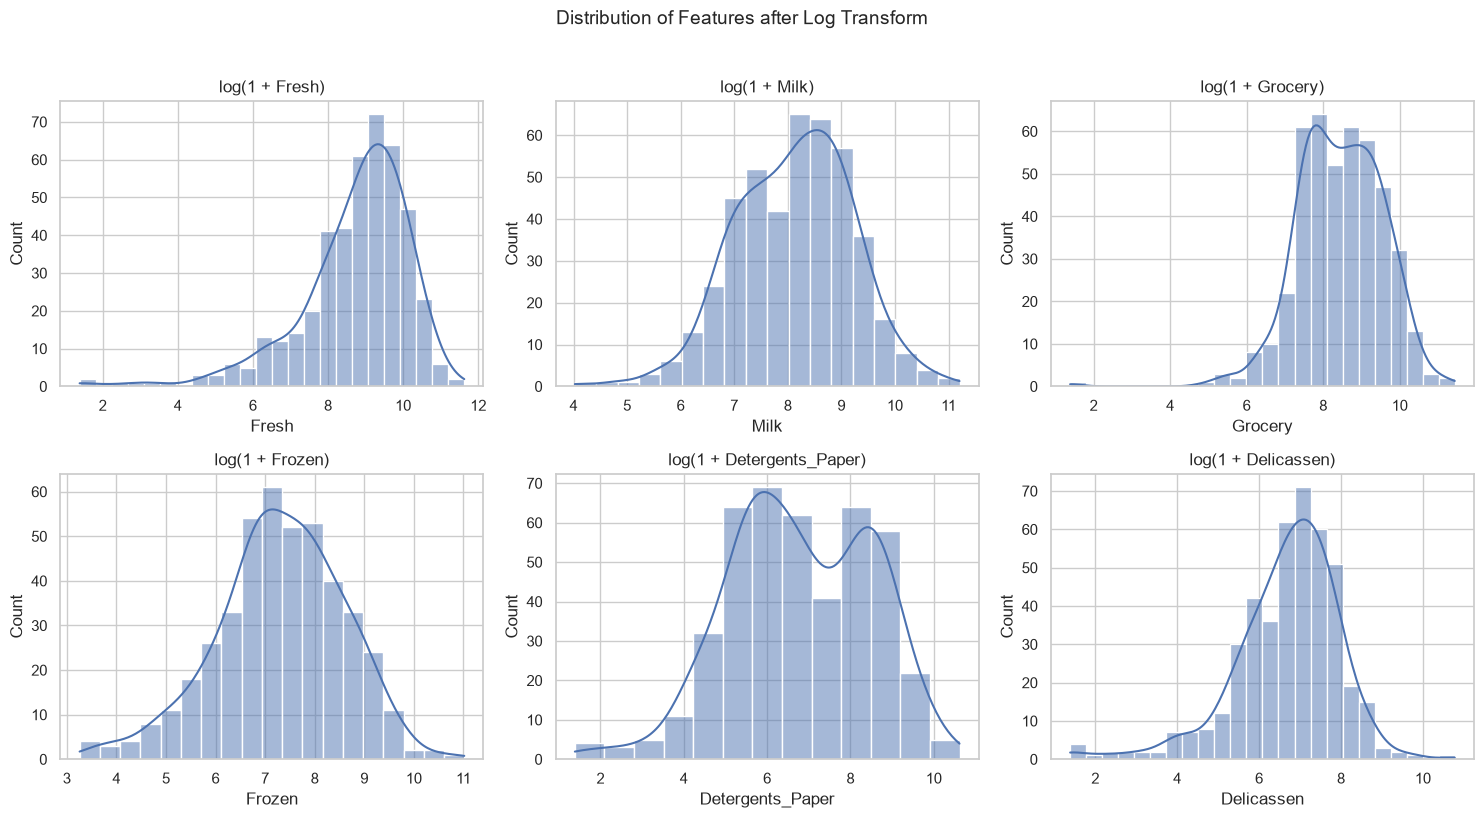

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, ax in zip(FEATURES, axes.flat):
    sns.histplot(np.log1p(df[column]), kde=True, ax=ax)
    ax.set_title(f"log(1 + {column})")
plt.suptitle("Distribution of Features after Log Transform", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## **III. How many clusters should K-Means create?**

K-Means requires us to specify the number of clusters in advance, denoted as 'k'. 
We experiment with k ranging from 2 to 8 and evaluate three metrics:

- Inertia: Are customers within the same cluster close to each other? Smaller is better, 
  but this metric always decreases as more clusters are added.
- Silhouette: Does a customer look more like their own cluster than other clusters? 
  Closer to 1 is better; closer to 0 means boundaries are overlapping and blurry.
- Calinski-Harabasz: Compares the internal tightness of clusters with the separation 
  between different clusters. Larger values are generally better.

The Silhouette metric might favor k=2, but two clusters are often too few for the marketing team 
to take distinct actions. We choose k=3 as a balanced decision between mathematical quality 
and practical business needs. This is an important example: metrics support decisions; 
they do not replace human judgment.


In [7]:
preprocessor = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), #better normalization
    ("scaler", StandardScaler())
])
X_scaled = preprocessor.fit_transform(df[FEATURES])
rows = []
models = {}
for k in range(2, 9): #2-> 8 clusters
    model = KMeans(n_clusters=k, n_init = 20,random_state=42)
    labels = model.fit_predict(X_scaled)
    models[k] = model
    # Silhouette: Evaluates each individual point to see if it is close to its 
    # assigned cluster and far from other clusters.
    # - Value range: [-1, 1]
    # - Closer to 1 => Highly accurate; Closer to -1 => Misclustered.

    # Calinski-Harabasz: Evaluates the entire dataset by comparing the variance 
    # between clusters against the variance within each individual cluster.
    # - Value range: 0 to +infinity (Larger values indicate better clustering).
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels)
    })
k_report = pd.DataFrame(rows) 
k_report.round(3)



,k,inertia,silhouette,calinski_harabasz
0,2,1844.064,0.290,189.050
1,3,1553.413,0.258,152.837
2,4,1386.863,0.188,131.320
3,5,1266.149,0.192,118.000
4,6,1174.536,0.195,108.300
5,7,1086.359,0.196,103.208
6,8,1024.047,0.191,97.386


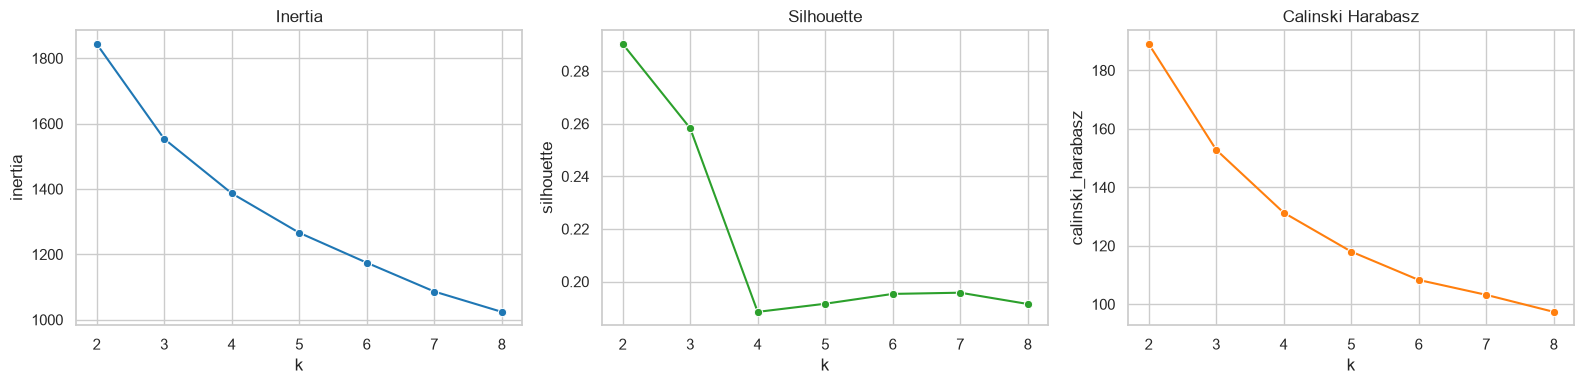

Best k by Silhouette: 2
Chosen k as a balance between mathematical quality and business needs: 3


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for metric, ax, color in zip(
    ["inertia", "silhouette", "calinski_harabasz"],
    axes, ["tab:blue", "tab:green", "tab:orange"]
):
    sns.lineplot(data=k_report, x="k", y=metric, marker="o", ax=ax, color=color)
    ax.set_title(metric.replace("_", " ").title())
plt.tight_layout()
plt.show()

best_silhouette_k = int(k_report.loc[k_report["silhouette"].idxmax(), "k"])
BUSINESS_K = 3
print(f"Best k by Silhouette: {best_silhouette_k}")
print(f"Chosen k as a balance between mathematical quality and business needs: {BUSINESS_K}")

## **IV. Understanding which customer profile each cluster represents**

After running K-Means, each customer is assigned a number such as 0, 1, or 2. 
These numbers are simply cluster IDs; cluster 2 is not "better" than cluster 1.

To label them, we look at the cluster centroids. A centroid can be understood as a representative 
customer created from the average spending of the entire group. The cell below automatically 
suggests three human-readable names. In a real project, business experts need to review 
the profile table and modify the names if the interpretation is incorrect.


In [9]:
kmeans = models[BUSINESS_K]
cluster_id = kmeans.labels_
df_segmented = df.copy()
df_segmented["cluster_id"] = cluster_id

cluster_centers_z = pd.DataFrame(kmeans.cluster_centers_, columns=FEATURES)
cluster_centers_z.index.name = "cluster_id"
cluster_centers_z.round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster_id,,,,,,
0,0.42,0.81,0.74,0.31,0.66,0.69
1,0.17,-0.73,-0.77,0.23,-0.75,-0.21
2,-1.16,0.46,0.67,-1.12,0.76,-0.67


In [12]:
#  Stable mapping based on centroid features, independent of random cluster IDs.
remaining = set(cluster_centers_z.index)
high_spend_id = cluster_centers_z.mean(axis=1).idxmax()
remaining.remove(high_spend_id)
retail_score = (
    cluster_centers_z["Grocery"] + cluster_centers_z["Detergents_Paper"]
    - cluster_centers_z["Fresh"] - cluster_centers_z["Frozen"]
)
retail_id = retail_score.loc[list(remaining)].idxmax()
remaining.remove(retail_id)
fresh_food_id = remaining.pop()

expert_label_map = {
    int(high_spend_id): "High & Diverse Spenders",
    int(retail_id): "Grocery & Consumer Goods",
    int(fresh_food_id): "Traditional Food Buyers",
}

df_segmented["segment_label"] = df_segmented["cluster_id"].map(expert_label_map)
expert_label_map

{0: 'High & Diverse Spenders',
 2: 'Grocery & Consumer Goods',
 1: 'Traditional Food Buyers'}

In [13]:
segment_profiles = (
    df_segmented.groupby(["cluster_id", "segment_label"])[FEATURES]
    .median()
    .round(0)
)
segment_counts = df_segmented["segment_label"].value_counts().rename("customers")
display(segment_profiles)
display(segment_counts.to_frame())

,,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster_id,segment_label,,,,,,
0,High & Diverse Spenders,12205.0,7209.0,9965.0,2033.0,3378.0,2005.0
1,Traditional Food Buyers,9635.0,1598.0,2151.0,2151.0,274.0,686.0
2,Grocery & Consumer Goods,1531.0,6154.0,10487.0,398.0,4196.0,490.0


,customers
segment_label,
Traditional Food Buyers,212
High & Diverse Spenders,145
Grocery & Consumer Goods,83


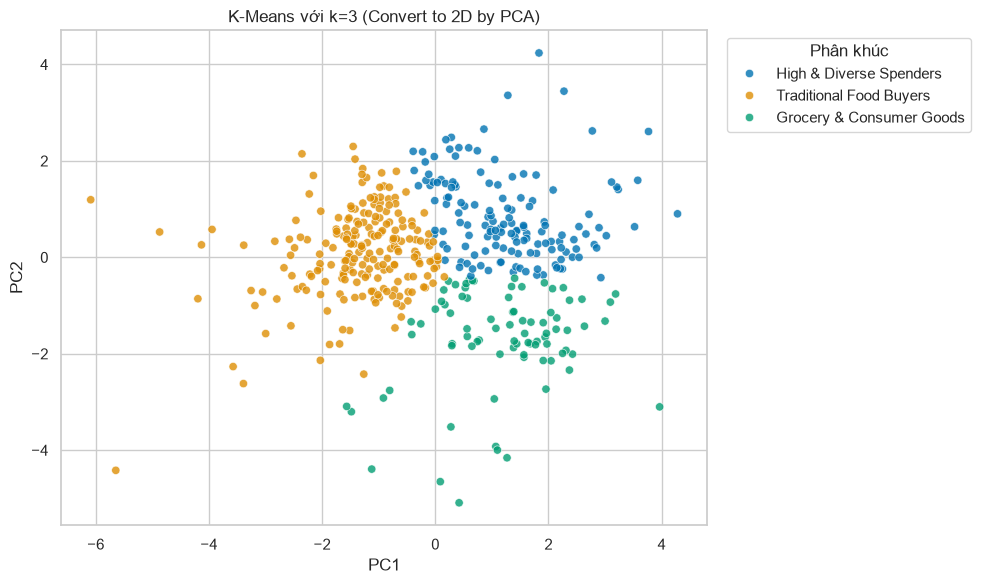

2 components explain 71.3% of the variance.


In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "segment_label": df_segmented["segment_label"],
})
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="segment_label", palette="colorblind", alpha=0.8)
plt.title(f"K-Means với k={BUSINESS_K} (Convert to 2D by PCA)")
plt.legend(title="Phân khúc", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(f"2 components explain {pca.explained_variance_ratio_.sum():.1%} of the variance.")

## **V. Which customers should be reviewed?**

Not every customer fits neatly into a single cluster.
- Points near the cluster centroid are typical customers, ideal for understanding the group.
- Points near the boundary between two clusters are borderline cases, which should be prioritized for review by human experts.

The results display both types. This serves as a bridge between machine-generated outputs and human decision-making, rather than assuming that every label generated by K-Means is completely correct.


In [18]:
distances = kmeans.transform(X_scaled)
sorted_distances = np.sort(distances, axis=1)
df_segmented["distance_to_centroid"] = distances[np.arange(len(df)), cluster_id]
df_segmented["boundary_margin"] = sorted_distances[:, 1] - sorted_distances[:, 0]

representatives = (
    df_segmented.sort_values("distance_to_centroid")
    .groupby("segment_label", group_keys=False)
    .head(3)
)
boundary_cases = df_segmented.nsmallest(10, "boundary_margin")

print("Typical samples close to centroids:")
display(representatives[["segment_label", *FEATURES, "distance_to_centroid"]])

print("Borderline samples near boundaries for priority expert review:")
display(boundary_cases[["segment_label", *FEATURES, "boundary_margin"]])


Typical samples close to centroids:


,segment_label,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,distance_to_centroid
1,High & Diverse Spenders,7057,9810,9568,1762,3293,1776,0.439950
389,Traditional Food Buyers,9385,1530,1422,3019,227,684,0.468929
415,High & Diverse Spenders,7842,6046,8552,1691,3540,1874,0.487234
374,Traditional Food Buyers,6338,2256,1668,1492,311,686,0.509379
426,High & Diverse Spenders,13134,9347,14316,3141,5079,1894,0.556115
246,Traditional Food Buyers,8885,2428,1777,1777,430,610,0.561487
172,Grocery & Consumer Goods,955,5479,6536,333,2840,707,0.702818
345,Grocery & Consumer Goods,1198,2602,8335,402,3843,303,0.732776
35,Grocery & Consumer Goods,688,5491,11091,833,4239,436,0.802783


Borderline samples near boundaries for priority expert review:


,segment_label,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,boundary_margin
428,Traditional Food Buyers,3047,5970,4910,2198,850,317,0.008453
160,Grocery & Consumer Goods,1725,3651,12822,824,4424,2157,0.009406
6,Grocery & Consumer Goods,12126,3199,6975,480,3140,545,0.017364
404,Traditional Food Buyers,18073,4613,3444,4324,914,715,0.021046
141,High & Diverse Spenders,30379,13252,5189,321,51,1450,0.024837
138,High & Diverse Spenders,13537,4257,5034,155,249,3271,0.032520
392,Grocery & Consumer Goods,518,4180,3600,659,122,654,0.039794
299,Traditional Food Buyers,444,879,2060,264,290,259,0.060471
393,High & Diverse Spenders,23632,6730,3842,8620,385,819,0.061316
239,High & Diverse Spenders,47493,2567,3779,5243,828,2253,0.070145


## **VI. Handing over results to KNN**

We add the 'segment_label' column to the dataset and save it as 'customers_segmented.csv'. 
This file acts as a "handover contract" between the two notebooks. 

From this work, group names are generated algorithmically based on cluster centroids. 
In a real-world project, experts should fix any improper labels before exporting the file. 
The KNN model in the next part will learn exactly from these handed-over labels.



In [19]:
df_segmented.to_csv("customers_segmented.csv", index=False)

print("Đã tạo customers_segmented.csv cho notebook KNN.")

Đã tạo customers_segmented.csv cho notebook KNN.


### **What have we just accomplished?**

Initially, the data consisted only of spending numbers without any segment columns. 
K-Means helped uncover three distinct behavioral patterns. After humans named the clusters 
and reviewed the borderline cases, the data now features a column of clean labels ready 
for supervised learning algorithms.

The subsequent KNN notebook will read 'customers_segmented.csv'. If an expert modifies 
some of the labels, KNN can learn directly from those human adjustments; it is not strictly 
bound to the original circular boundaries around the K-Means centroids.